In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# loading the datasets.
pgcb=pd.read_excel("/content/PGCB_date_power_demand.xlsx")
wea=pd.read_excel("/content/weather_data.xlsx",skiprows=3)
eco=pd.read_csv("/content/economic_full_1.csv")


In [78]:
# size, structure, and data types of dataset PGCB

print(pgcb.head())
print(pgcb.shape)
print(pgcb.info())


             datetime  generation_mw  demand_mw  load_shedding   gas  \
0 2015-04-19 22:00:00         6323.0       6323              0     0   
1 2015-04-19 21:00:00         6667.0       6667              0     0   
2 2015-04-19 19:00:00         6897.0       6897              0  4415   
3 2015-04-19 18:30:00         6933.0       6933              0  4423   
4 2015-04-19 18:00:00         6874.0       6874              0  4319   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    NaN   NaN                     0              0   
1            0     0      0    NaN   NaN                     0              0   
2         1836   161     41    NaN   NaN                   444              0   
3         1862   159     45    NaN   NaN                   444              0   
4         1892   155     65    NaN   NaN                   443              0   

   india_adani  nepal       remarks  
0          NaN    NaN           NaN  
1   

In [79]:
# size, structure, and data types of dataset weather_data
print(wea.head())
print(wea.shape)
print(wea.info())

print(wea.columns.tolist())

                 time  temperature_2m (°C)  relative_humidity_2m (%)  \
0 2014-01-01 00:00:00                 13.9                        89   
1 2014-01-01 01:00:00                 13.6                        91   
2 2014-01-01 02:00:00                 13.3                        91   
3 2014-01-01 03:00:00                 13.0                        92   
4 2014-01-01 04:00:00                 12.7                        93   

   apparent_temperature (°C)  precipitation (mm)  dew_point_2m (°C)  \
0                       13.3                 0.0               12.1   
1                       13.2                 0.0               12.1   
2                       12.8                 0.0               11.9   
3                       12.5                 0.0               11.8   
4                       12.2                 0.0               11.6   

   soil_temperature_0_to_7cm (°C)  wind_direction_10m (°)  cloud_cover (%)  \
0                            16.4                     313     

In [80]:
# size, structure, and data types of dataset economic_full_1
print(eco.head())
print(eco.shape)
print(eco.info())

  Country Name                                     Indicator Name  \
0            X     Intentional homicides, male (per 100,000 male)   
1            X           Battle-related deaths (number of people)   
2            X          Voice and Accountability: Percentile Rank   
3            X  Transport services (% of commercial service ex...   
4            X  Computer, communications and other services (%...   

      Indicator Code  1960  1961  1962  1963  1964  1965  1966  ...  \
0  VC.IHR.PSRC.MA.P5   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
1        VC.BTL.DETH   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
2         VA.PER.RNK   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
3  TX.VAL.TRAN.ZS.WT   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
4  TX.VAL.OTHR.ZS.WT   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   

        2016       2017       2018       2019       2020       2021  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1  41.000000  47

In [81]:

wea.rename(columns={'time': 'datetime'}, inplace=True)
print(wea['datetime'].dtype)
hourly_df = pd.merge(pgcb, wea, on='datetime', how='inner')
print("Merged Shape:", hourly_df.shape)



datetime64[ns]
Merged Shape: (88469, 24)


In [82]:

print(eco.columns.tolist())
print(eco['Indicator Name'].head(10))

['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
0       Intentional homicides, male (per 100,000 male)
1             Battle-related deaths (number of people)
2            Voice and Accountability: Percentile Rank
3    Transport services (% of commercial service ex...
4    Computer, communications and other services (%...
5    Merchandise exports by the reporting economy, ...
6    Merchandise exports to low- and middle-income ...
7    Merchandise exports to high-i

In [94]:
hourly_df['year'] = hourly_df['datetime'].dt.year
years_to_keep = [str(y) for y in range(2014, 2026)]
econ_long = pd.melt(
    eco,
    id_vars=['Indicator Name'],
    value_vars=years_to_keep,
    var_name='year',
    value_name='Value'
)
econ_long['year'] = econ_long['year'].astype(int)
econ_ready = econ_long.pivot_table(index='year', columns='Indicator Name', values='Value').reset_index()
final_df = pd.merge(hourly_df, econ_ready, on='year', how='left')



In [95]:
final_df.columns = final_df.columns.str.strip().str.lower()

demand_col = [col for col in final_df.columns if 'demand' in col][0]
gdp_col = [col for col in final_df.columns if 'gdp' in col][0]
pop_col = [col for col in final_df.columns if 'population' in col][0]
temp_col = [col for col in final_df.columns if 'temperature_2m' in col][0]
humidity_col = [col for col in final_df.columns if 'humidity' in col][0]
wind_col = [col for col in final_df.columns if 'wind' in col][0]

columns_to_keep = [
    'datetime',
    demand_col,
    temp_col,
    humidity_col,
    wind_col,
    gdp_col,
    pop_col
]
cleaned_df = final_df[columns_to_keep].copy()
cleaned_df[gdp_col] = cleaned_df[gdp_col].ffill().bfill()
cleaned_df[pop_col] = cleaned_df[pop_col].ffill().bfill()

print(cleaned_df.isnull().sum())

datetime                                                                    0
demand_mw                                                                   0
temperature_2m (°c)                                                         0
relative_humidity_2m (%)                                                    0
wind                                                                    70539
agriculture, forestry, and fishing, value added (% of gdp)                  0
access to clean fuels and technologies for cooking (% of population)        0
dtype: int64


In [99]:
cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'])
cleaned_df['hour'] = cleaned_df['datetime'].dt.hour
cleaned_df['day_of_week'] = cleaned_df['datetime'].dt.dayofweek
cleaned_df['month'] = cleaned_df['datetime'].dt.month
cleaned_df['is_weekend'] = (cleaned_df['datetime'].dt.dayofweek >= 5).astype(int)
model_df = cleaned_df.drop(columns=['datetime'])
print("Feature Engineering Complete!")
print(model_df.head())

Feature Engineering Complete!
   demand_mw  temperature_2m (°c)  relative_humidity_2m (%)  wind  \
0       6323                 26.0                        91   NaN   
1       6667                 26.2                        90   NaN   
2       6897                 27.3                        85   NaN   
3       6874                 28.3                        81   NaN   
4       5725                 29.1                        78   NaN   

   agriculture, forestry, and fishing, value added (% of gdp)  \
0                                          14.782996            
1                                          14.782996            
2                                          14.782996            
3                                          14.782996            
4                                          14.782996            

   access to clean fuels and technologies for cooking (% of population)  hour  \
0                                               18.1                       22   
1 

In [101]:
y = model_df['demand_mw']
X = model_df.drop(columns=['demand_mw'])
split_index = int(len(model_df) * 0.80)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print(f"Training Features (X_train) Shape: {X_train.shape}")
print(f"Testing Features (X_test) Shape: {X_test.shape}")

Training Features (X_train) Shape: (70775, 9)
Testing Features (X_test) Shape: (17694, 9)


In [104]:
from xgboost import XGBRegressor
import time

xgb_model = XGBRegressor(
    n_estimators=100,      # Number of trees to build
    learning_rate=0.1,     # Step size
    max_depth=6,           # Maximum depth
    random_state=42        # Ensures we get the exact same results every time
)

xgb_model.fit(X_train, y_train)
predictions = xgb_model.predict(X_test)
for i in range(5):
    actual = y_test.iloc[i]
    predicted = predictions[i]
    error = abs(actual - predicted)
    print(f"Actual: {actual} MW | Predicted: {round(predicted, 1)} MW | Missed by: {round(error, 1)} MW")

Actual: 13500 MW | Predicted: 13692.0 MW | Missed by: 192.0 MW
Actual: 13600 MW | Predicted: 13959.7001953125 MW | Missed by: 359.7 MW
Actual: 14040 MW | Predicted: 14241.2998046875 MW | Missed by: 201.3 MW
Actual: 13940 MW | Predicted: 14890.2001953125 MW | Missed by: 950.2 MW
Actual: 13450 MW | Predicted: 14164.7001953125 MW | Missed by: 714.7 MW


In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = np.mean(np.abs((y_test - predictions) / (y_test + 1e-10))) * 100
print(f"Mean Absolute Error (MAE): {round(mae, 2)} MW")
print(f"Root Mean Sq. Error (RMSE): {round(rmse, 2)} MW")
print(f"Mean Abs. Percentage Error (MAPE): {round(mape, 2)}%")

Mean Absolute Error (MAE): 928.16 MW
Root Mean Sq. Error (RMSE): 1851.04 MW
Mean Abs. Percentage Error (MAPE): 9.63%


/tmp/ipykernel_6193/1930337060.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_data, palette='viridis')


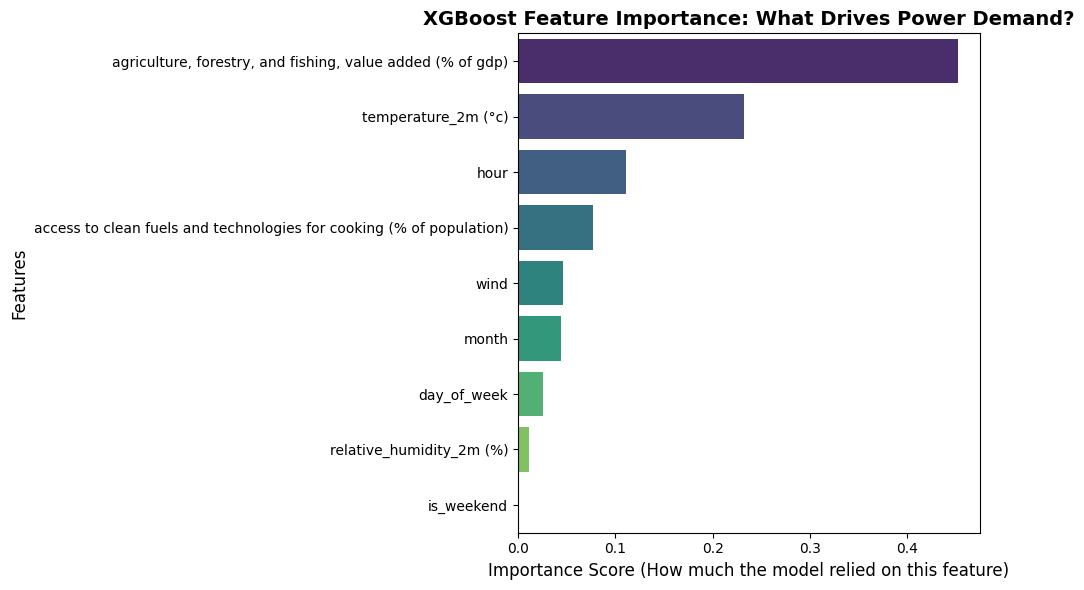

In [110]:
importance_data = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance_data = importance_data.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_data, palette='viridis')
plt.title('XGBoost Feature Importance: What Drives Power Demand?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (How much the model relied on this feature)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [112]:
import joblib
model_filename = 'xgboost_power_demand_model.pkl'
joblib.dump(xgb_model, model_filename)

['xgboost_power_demand_model.pkl']

This model has,

Mean Absolute Error (MAE): 928.16 MW

Root Mean Sq. Error (RMSE): 1851.04 MW

Mean Abs. Percentage Error (MAPE): 9.63%

This means that, on average, the model's predictions deviate by less than 10% from the actual megawatt demand when tested on a completely unseen, future timeframe. I have used a strict 80-20 split in data to train and test the model.

# **Summary & Interpretation**

**1. Handling Missing Data and Anomalies:**
* **Data Cleaning:** The original dataset had hidden spaces in the column headers (like 'demand_mw '), which caused indexing errors. I stripped all hidden spaces and converted headers to lowercase to fix this.
* **Filling Missing Values:** The World Bank economic data was missing values for 2024 and 2025. Since macroeconomic indicators stay relatively stable, I used forward-fill (ffill) and backward-fill (bfill) to patch the missing years.

**2. Feature Engineering:**
* **Time Features:** Machine learning models can't read raw date strings, so I extracted the hour, day_of_week, and month from the datetime column, and created a binary is_weekend feature. This helps the model learn daily and weekly routines.
* **External Data:** I merged weather data (temperature, humidity, wind) and economic data (GDP, population) so the model could learn both immediate weather impacts and long-term growth trends.

**3. Key Insights from Feature Importance:**
Based on the model's feature importance chart, the top three drivers of power demand are:
1. **Agriculture/GDP:** This is the most important feature. It sets the long-term baseline because as the economy grows, the overall demand for electricity permanently increases.
2. **Temperature:** This drives major short-term fluctuations, like power grids spiking when people run air conditioners or heaters.
3. **Hour of the day:** This captures human daily routines, like the sudden surge in power usage when people return home from work in the evening.